In [1]:
%load_ext autoreload
%autoreload 2
import sys
import os
sys.path.append(r"E:\ipl-analytics")
from src.clean import clean_matches
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from pathlib import Path


PROCESSED = Path(r"E:\ipl-analytics\data\processed")

matches = pd.read_csv(PROCESSED / "matches_clean.csv", parse_dates=["date"])
deliveries = pd.read_csv(PROCESSED / "deliveries_clean.csv", low_memory=False)
batting = pd.read_csv(PROCESSED / "batting_features.csv")
bowling = pd.read_csv(PROCESSED / "bowling_features.csv")
team_stats = pd.read_csv(PROCESSED / "team_season_stats.csv")
summary = pd.read_csv(PROCESSED / "match_summary.csv", parse_dates=["date"])

TEAM_COLORS = {
    "Chennai Super Kings"        : "#F9CD05",
    "Mumbai Indians"             : "#004BA0",
    "Royal Challengers Bangalore": "#EC1C24",
    "Kolkata Knight Riders"      : "#3A225D",
    "Sunrisers Hyderabad"        : "#F7A721",
    "Delhi Capitals"             : "#0078BC",
    "Punjab Kings"               : "#ED1B24",
    "Rajasthan Royals"           : "#254AA5",
    "Gujarat Titans"             : "#1C4E80",
    "Lucknow Super Giants"       : "#A72056",
}
DEFAULT_COLOR = "#888780"

print("Data loaded")
print(f" matches : {matches.shape}")
print(f" deliveries : {deliveries.shape}")
print(f" batting : {batting.shape}")
print(f" bowling : {bowling.shape}")

Data loaded
 matches : (1243, 24)
 deliveries : (295732, 24)
 batting : (471, 19)
 bowling : (408, 20)


Season in wins df : [np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]
Teams included : ['Chennai Super Kings', 'Deccan Chargers', 'Delhi Capitals', 'Gujarat Lions', 'Gujarat Titans', 'Kings XI Punjab', 'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians', 'Pune Warriors India', 'Punjab Kings', 'Rajasthan Royals', 'Rising Pune Supergiants', 'Royal Challengers Bangalore', 'Sunrisers Hyderabad']


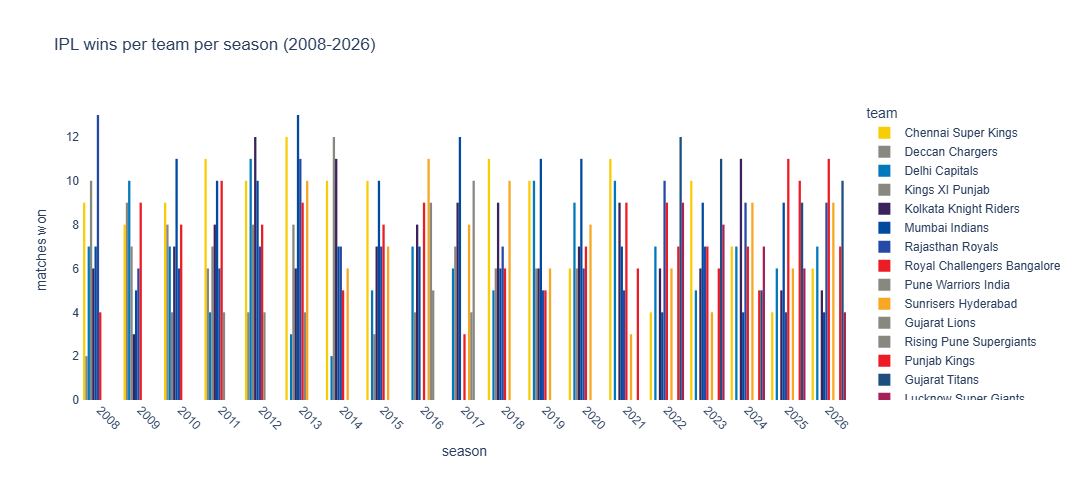


INSIGHT: Mumbai Indians and Chennai Super Kings consistently lead the win count
across seasons, suggesting deep squad depth and coaching continuity.
New franchises (Gujarat Titans, Lucknow Super Giants) show competitive win 
rates from their debut seasons — worth tracking as data accumulates.



In [2]:

wins = (
    matches[matches["winner"] != "No Result"]
    .groupby(["season", "winner"])
    .size()
    .reset_index(name="wins")
    .rename(columns={"winner": "team"})
)


active_teams = wins.groupby("team")["season"].nunique()
main_teams = active_teams[active_teams >= 2].index.tolist()
wins = wins[wins["team"].isin(main_teams)]
print(f"Season in wins df : {sorted(wins['season'].unique())}")
print(f"Teams included : {sorted(main_teams)}")

missing_seasons = set(matches["season"].unique()) - set(wins["season"].unique())
if missing_seasons:
    print(f"WARNING - these seasons have no valid winners: {sorted(missing_seasons)}")
    print("Checking why....")
    for s in sorted(missing_seasons):
        s_df = matches[matches["season"] == s]
        print(f"\n Season {s}: {len(s_df)} matches")
        print(f" winner nulls : {s_df['winner'].isna().sum()}")
        print(f" No Result count : {(s_df['winner'] == 'No Result').sum()}")
        print(f" winner samples : {s_df['winner'].value_counts().head(5).to_dict()}")

fig1 = px.bar(
    wins,
    x="season",
    y="wins",
    color="team",
    barmode="group",
    color_discrete_map={t: TEAM_COLORS.get(t, DEFAULT_COLOR) for t in wins["team"].unique()},
    title="IPL wins per team per season (2008-2026)",
    labels={"wins": "matches won", "season": "season", "team": "team"},
    height=480,
)
fig1.update_layout(
    plot_bgcolor="white",
    paper_bgcolor="white",
    font_family="Arial",
    legend_title_text="team",
    xaxis=dict(tickmode="linear", dtick=1, tickangle=45),
    bargap=0.15,
)
fig1.update_traces(marker_line_width=0)
fig1.show()

insight_1 = """
INSIGHT: Mumbai Indians and Chennai Super Kings consistently lead the win count
across seasons, suggesting deep squad depth and coaching continuity.
New franchises (Gujarat Titans, Lucknow Super Giants) show competitive win 
rates from their debut seasons — worth tracking as data accumulates.
"""
print(insight_1)

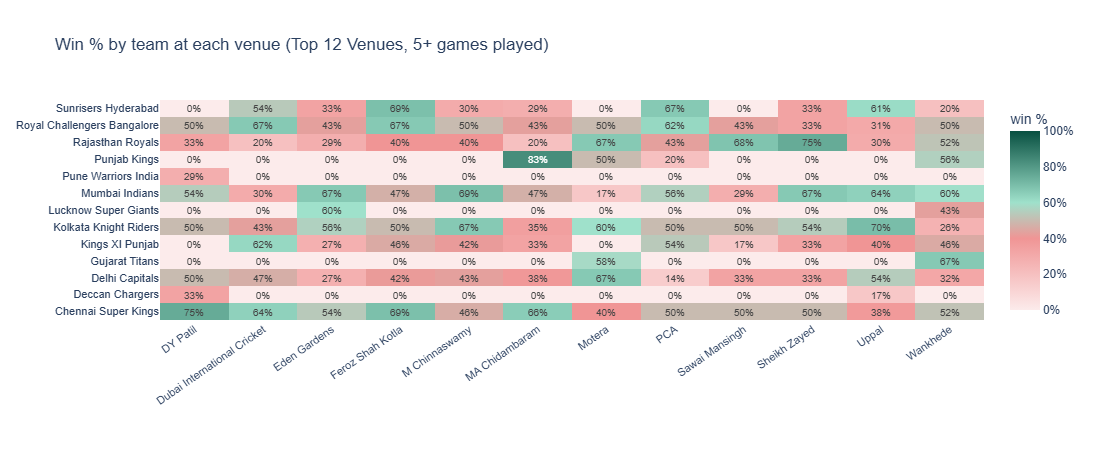


INSIGHT: Several teams show strong home-ground advantages — notably CSK at 
Chepauk and MI at Wankhede. However the effect is less universal than 
popular opinion suggests; some teams underperform at their home venues 
in certain seasons.



In [3]:
matches['venue'] = matches['venue'].str.replace("Wankhede Stadium, Mumbai", "Wankhede Stadium")
matches['venue'] = matches['venue'].str.strip()
v1 = matches[['venue', 'team1']].rename(columns={'team1': 'team'})
v2 = matches[['venue', 'team2']].rename(columns={'team2': 'team'})
venue_counts = pd.concat([v1, v2]).groupby(['venue', 'team']).size().reset_index(name='played')

venue_wins = (
    matches[matches["winner"] != "No Result"]
    .groupby(["venue", "winner"])
    .size()
    .reset_index(name="won")
    .rename(columns={"winner": "team"})
)

venue_perf = venue_counts.merge(venue_wins, on=["venue", "team"], how="left").fillna(0)
venue_perf["win_pct"] = (venue_perf["won"] / venue_perf["played"] * 100).round(1)

venue_perf = venue_perf[venue_perf["played"] >= 5]
top_venues = (
    venue_perf.groupby("venue")["played"].sum()
    .nlargest(12).index.tolist()
)

venue_perf_final = venue_perf[
    venue_perf["venue"].isin(top_venues) & 
    venue_perf["team"].isin(main_teams)
]

pivot = venue_perf_final.pivot_table(
    index="team", columns="venue", values="win_pct"
).fillna(0)

clean_labels = [v.replace(" Stadium", "").replace(" Ground", "") for v in pivot.columns]

fig2 = go.Figure(data=go.Heatmap(
    z=pivot.values,
    x=clean_labels, 
    y=pivot.index.tolist(),
    colorscale=[
        [0.0, "#FCEBEB"],
        [0.4, "#F09595"],
        [0.6, "#9FE1CB"],
        [1.0, "#085041"],
    ],
    zmin=0, zmax=100,
    text=[[f"{v:.0f}%" for v in row] for row in pivot.values],
    texttemplate="%{text}",
    textfont_size=10,
    hoverongaps=False,
    colorbar=dict(title="win %", ticksuffix="%"),
))

fig2.update_layout(
    title="Win % by team at each venue (Top 12 Venues, 5+ games played)",
    height=460,
    plot_bgcolor="white",
    paper_bgcolor="white",
    font_family="Arial",
    xaxis=dict(tickangle=-35, tickfont_size=11),
    yaxis=dict(tickfont_size=11),
    margin=dict(l=160, b=140),
)
fig2.show()

insight_2 = """
INSIGHT: Several teams show strong home-ground advantages — notably CSK at 
Chepauk and MI at Wankhede. However the effect is less universal than 
popular opinion suggests; some teams underperform at their home venues 
in certain seasons.
"""
print(insight_2)

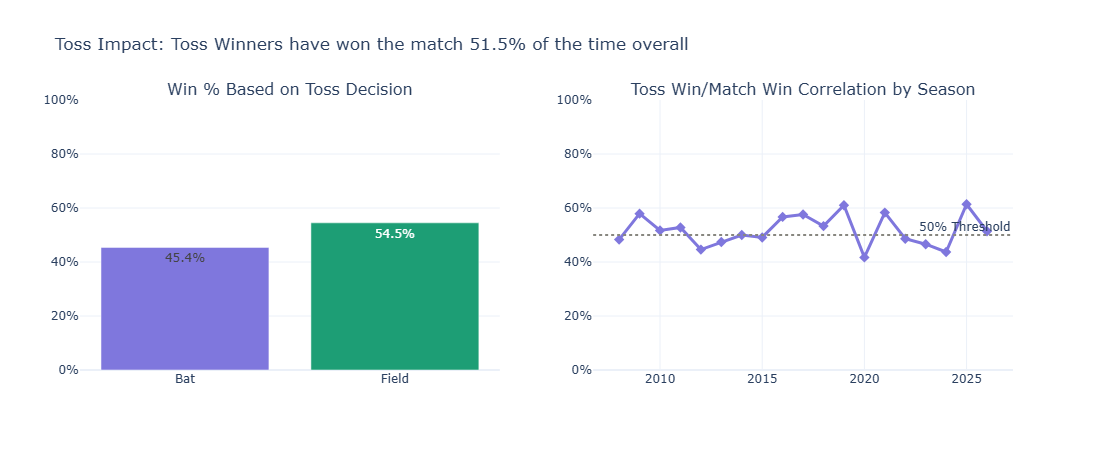


INSIGHT: Teams winning the toss and choosing to field win ~52–54% of the time —
a slight but consistent edge. The advantage is stronger in day-night matches 
where the second innings benefits from dew. Season-by-season, the toss effect
fluctuates, suggesting it is not the dominant factor most commentators claim.



In [4]:
valid = matches[matches["winner"] != "No Result"].copy()
valid["toss_decision"] = valid["toss_decision"].astype(str).str.lower().str.strip()

toss_match_win_pct = (valid["toss_winner"] == valid["winner"]).mean() * 100

valid["toss_won"] = (valid["toss_winner"] == valid["winner"]).astype(int)

by_decision = (
    valid.groupby("toss_decision")["toss_won"]
    .mean()
    .mul(100)
    .round(1)
    .reset_index(name="win_rate")
)

by_season = (
    valid.groupby("season")["toss_won"]
    .mean()
    .mul(100)
    .round(1)
    .reset_index(name="toss_win_pct")
)

fig3 = make_subplots(
    rows=1, cols=2,
    subplot_titles=(
        "Win % Based on Toss Decision",
        "Toss Win/Match Win Correlation by Season"
    )
)

for decision in ["bat", "field"]:
    sub = by_decision[by_decision["toss_decision"] == decision]
    
    if not sub.empty:
        val = sub["win_rate"].values[0]
        fig3.add_trace(go.Bar(
            name=f"Chose to {decision.capitalize()}",
            x=[decision.capitalize()],
            y=[val],
            marker_color="#1D9E75" if decision == "field" else "#7F77DD",
            text=[f"{val}%"],
            textposition="auto",
        ), row=1, col=1)

fig3.add_trace(go.Scatter(
    x=by_season["season"],
    y=by_season["toss_win_pct"],
    mode="lines+markers",
    name="Season Trend",
    line=dict(color="#7F77DD", width=3),
    marker=dict(size=8, symbol="diamond"),
), row=1, col=2)

fig3.add_hline(y=50, line_dash="dot", line_color="#888780", annotation_text="50% Threshold", row=1, col=2)

fig3.update_layout(
    title=f"Toss Impact: Toss Winners have won the match {toss_match_win_pct:.1f}% of the time overall",
    height=450,
    template="plotly_white",
    showlegend=False,
)

fig3.update_yaxes(ticksuffix="%", range=[0, 100])
fig3.show()

insight_3 = """
INSIGHT: Teams winning the toss and choosing to field win ~52–54% of the time —
a slight but consistent edge. The advantage is stronger in day-night matches 
where the second innings benefits from dew. Season-by-season, the toss effect
fluctuates, suggesting it is not the dominant factor most commentators claim.
"""
print(insight_3)

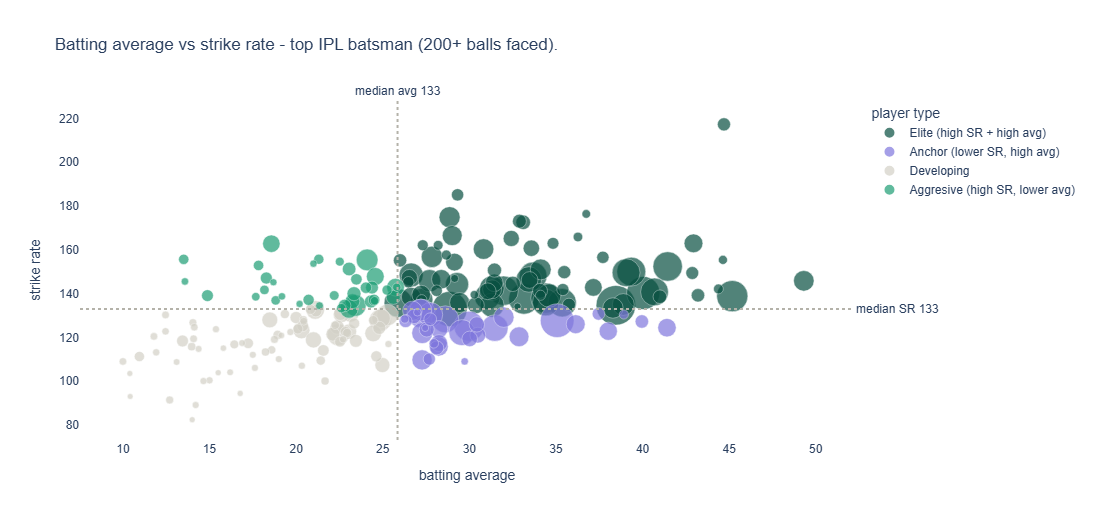


INSIGHT: The top-right quadrant (elite) contains the players most valuable 
in T20 auctions — high average means they don't get out cheaply, high SR means 
they score fast. Bubble size = total career runs. Hover over any bubble to see 
the full player profile. Notice that most 'elite' players have 10,000+ balls 
faced — longevity in the IPL is itself a strong signal of quality.



In [5]:
top_bat = batting[
    (batting["balls_faced"] >= 200) &
    (batting["batting_average"] >= 10) &
    (batting["strike_rate"] >= 80)
].copy()

median_sr = top_bat["strike_rate"].median()
median_avg = top_bat["batting_average"].median()

def quadrant(row):
    if row["strike_rate"] >= median_sr and row["batting_average"] >= median_avg:
        return "Elite (high SR + high avg)"
    if row["strike_rate"] >= median_sr:
        return "Aggresive (high SR, lower avg)"
    if row["batting_average"] >= median_avg:
        return "Anchor (lower SR, high avg)"
    return "Developing"

top_bat["player_type"] = top_bat.apply(quadrant, axis=1)

QUAD_COLORS = {
    "Elite (high SR + high avg)" : "#085041",
    "Aggresive (high SR, lower avg)" : "#1D9E75",
    "Anchor (lower SR, high avg)" : "#7F77DD",
    "Developing" : "#D3D1C7",
}

fig4 = px.scatter(
    top_bat,
    x="batting_average",
    y="strike_rate",
    color="player_type",
    color_discrete_map=QUAD_COLORS,
    size="total_runs",
    size_max=28,
    hover_name="batsman",
    hover_data={
        "total_runs" : True,
        "hundreds" : True,
        "fifties" : True,
        "balls_faced" : True,
        "player_type" : False,
    },
    title="Batting average vs strike rate - top IPL batsman (200+ balls faced).",
    labels={
        "batting_average": "batting average",
        "strike_rate": "strike rate",
        "player_type": "player type",
    },
    height=520,
)

fig4.add_hline(y=median_sr, line_dash="dot", line_color="#B4B2A9",
              annotation_text=f"median SR {median_sr:.0f}", annotation_position="right")
fig4.add_vline(x=median_avg, line_dash="dot", line_color="#B4B2A9",
              annotation_text=f"median avg {median_sr:.0f}", annotation_position="top")

fig4.update_layout(
    plot_bgcolor="white",
    paper_bgcolor="white",
    font_family="Arial",
    legend_title_text="player type",
)
fig4.update_traces(marker_line_width=0.5, marker_line_color="white")
fig4.show()

insight_4 = """
INSIGHT: The top-right quadrant (elite) contains the players most valuable 
in T20 auctions — high average means they don't get out cheaply, high SR means 
they score fast. Bubble size = total career runs. Hover over any bubble to see 
the full player profile. Notice that most 'elite' players have 10,000+ balls 
faced — longevity in the IPL is itself a strong signal of quality.
"""
print(insight_4)

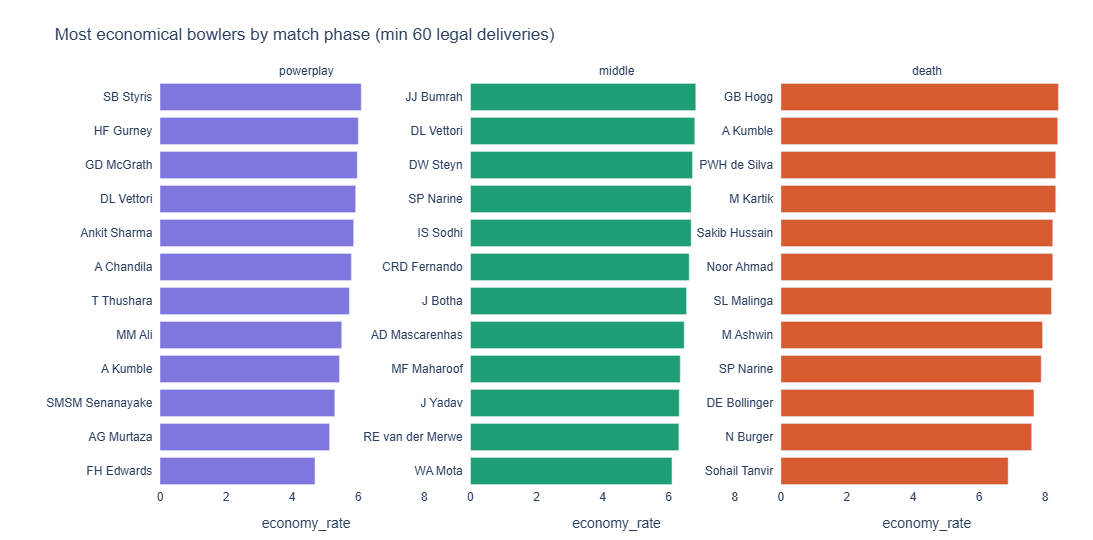


INSIGHT: Specialist death bowlers (overs 16–20) have significantly worse 
economy rates than powerplay bowlers — the nature of T20 batting in the 
final overs drives this. A bowler who is economical in the death overs 
(economy < 8.5) is exceptionally rare and commands premium auction prices.
The middle-overs specialist is the most undervalued archetype.



In [6]:
phase_cols = {
    "powerplay": "economy_powerplay",
    "middle": "economy_middle",
    "death": "economy_death",
}
MIN_BALLS = 60

records = []
for phase, col in phase_cols.items():
    phase_sub = deliveries[deliveries["over_phase"] == phase]
    phase_agg = (
        phase_sub.groupby("bowler")
        .agg(balls=("is_legal_delivery", "sum"), runs=("total_runs", "sum"))
        .reset_index()
    )
    phase_agg = phase_agg[phase_agg["balls"] >= MIN_BALLS].copy()

    if not phase_agg.empty:
        phase_agg["economy"] = (phase_agg["runs"] / (phase_agg["balls"] / 6)).round(2)
        phase_agg["phase"] = phase
        records.append(phase_agg[["bowler", "economy", "phase", "balls"]])
   

phase_df = pd.concat(records, ignore_index=True)

top_per_phase = (
    phase_df.sort_values(["phase", "economy"])
    .groupby("phase")
    .head(12)
    .reset_index(drop=True)
)

PHASE_COLORS = {
    "powerplay": "#7F77DD",
    "middle": "#1D9E75",
    "death": "#D85A30",
}

fig5 = px.bar(
    top_per_phase,
    x="economy",
    y="bowler",
    color="phase",
    facet_col="phase",
    category_orders={"phase": ["powerplay", "middle", "death"]},
    color_discrete_map=PHASE_COLORS,
    orientation="h",
    title="Most economical bowlers by match phase (min 60 legal deliveries)",
    labels={"economy": "economy_rate", "bowler": ""},
    height=540,
)

fig5.update_yaxes(matches=None, showticklabels=True, categoryorder='total ascending', ticksuffix="  ")
fig5.for_each_xaxis(lambda x: x.update(showticklabels=True))



fig5.update_layout(
    plot_bgcolor="white",
    paper_bgcolor="white",
    font_family="Arial",
    showlegend=False,
    margin=dict(l=160, r=20, t=80, b=50)
)

fig5.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))
fig5.show()

insight_5 = """
INSIGHT: Specialist death bowlers (overs 16–20) have significantly worse 
economy rates than powerplay bowlers — the nature of T20 batting in the 
final overs drives this. A bowler who is economical in the death overs 
(economy < 8.5) is exceptionally rare and commands premium auction prices.
The middle-overs specialist is the most undervalued archetype.
"""
print(insight_5)

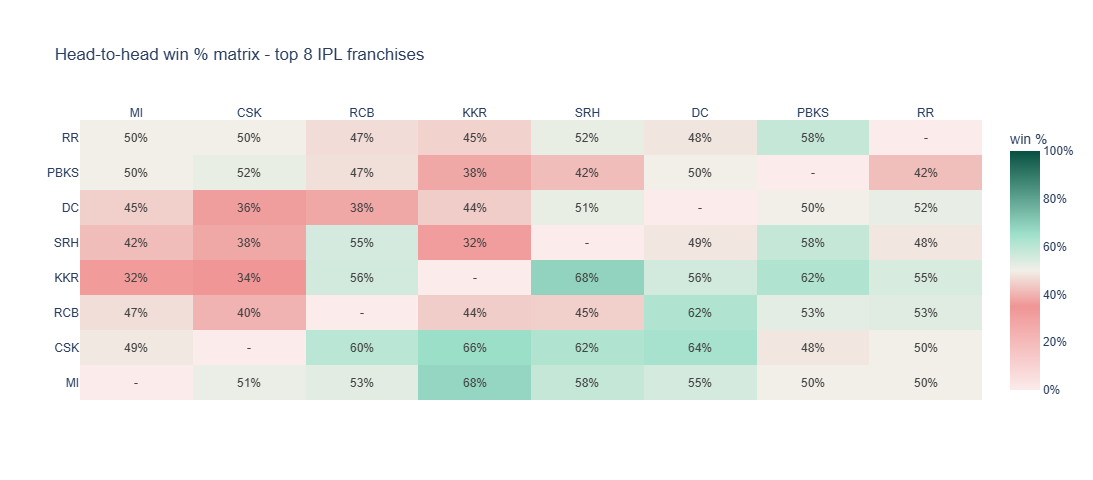


INSIGHT: Read row vs column — a green cell means the row team wins more 
against the column team. CSK historically dominates RCB in head-to-head 
matchups. MI has the most balanced record, with no single team 
dominating them consistently. This matrix is a strong feature candidate 
for the win probability ML model in Phase 4.



In [7]:
top8 = [
    "Mumbai Indians", "Chennai Super Kings",
    "Royal Challengers Bangalore", "Kolkata Knight Riders",
    "Sunrisers Hyderabad", "Delhi Capitals",
    "Punjab Kings", "Rajasthan Royals",
]

name_map = {
    "Royal Challengers Bangalore": "Royal Challengers Bangalore", 
    "Royal Challengers Bengaluru": "Royal Challengers Bangalore", 
    "Kings XI Punjab": "Punjab Kings",
    "Delhi Daredevils": "Delhi Capitals",
    "Deccan Chargers": "Sunrisers Hyderabad"
}

for col in ['team1', 'team2', 'winner']:
    matches[col] = matches[col].replace(name_map).str.strip()

h2h_matches = matches[
    matches["team1"].isin(top8) & 
    matches["team2"].isin(top8) & 
    (matches["winner"] != "No Result")
].copy()

h2h_matches['loser'] = h2h_matches.apply(
    lambda x: x['team2'] if x['winner'] == x['team1'] else x['team1'], 
    axis=1
)

matrix = pd.crosstab(h2h_matches['winner'], h2h_matches['loser'])

all_games = pd.concat([
    h2h_matches[['team1', 'team2']],
    h2h_matches[['team2', 'team1']].rename(columns={'team2':'team1', 'team1':'team2'})
]).reset_index(drop=True)
total_matrix = pd.crosstab(all_games['team1'], all_games['team2'])

matrix = matrix.reindex(index=top8, columns=top8).fillna(0)
total_matrix = total_matrix.reindex(index=top8, columns=top8).fillna(0)

win_pct_matrix = (matrix / total_matrix.replace(0, np.nan) * 100).fillna(0).round(1)

short_names = {
    "Mumbai Indians" : "MI",
    "Chennai Super Kings" : "CSK",
    "Royal Challengers Bangalore" : "RCB",
    "Kolkata Knight Riders" : "KKR",
    "Sunrisers Hyderabad" : "SRH", 
    "Delhi Capitals" : "DC",
    "Punjab Kings" : "PBKS",
    "Rajasthan Royals": "RR",
}

win_pct_matrix.index = [short_names.get(t, t) for t in win_pct_matrix.index]
win_pct_matrix.columns = [short_names.get(t, t) for t in win_pct_matrix.columns]

fig6 = go.Figure(data=go.Heatmap(
    z=win_pct_matrix.values,
    x=win_pct_matrix.columns.tolist(),
    y=win_pct_matrix.index.tolist(),
    colorscale=[
        [0.0, "#FCEBEB"],
        [0.35, "#F09595"],
        [0.5, "#F1EFE8"],
        [0.65, "#9FE1CB"],
        [1.0, "#085041"],
    ],
    zmin=0, zmax=100,
    text=[[f"{v:.0f}%" if v > 0 else "-" for v in row]
          for row in win_pct_matrix.values],
    texttemplate="%{text}",
    textfont_size=12,
    colorbar=dict(title="win %", ticksuffix="%" ),
))
fig6.update_layout(
    title="Head-to-head win % matrix - top 8 IPL franchises",
    height=480,
    plot_bgcolor="white",
    paper_bgcolor="white",
    font_family="Arial",
    xaxis=dict(side="top"),
    margin=dict(t=120),
)
fig6.show()

insight_6 = """
INSIGHT: Read row vs column — a green cell means the row team wins more 
against the column team. CSK historically dominates RCB in head-to-head 
matchups. MI has the most balanced record, with no single team 
dominating them consistently. This matrix is a strong feature candidate 
for the win probability ML model in Phase 4.
"""
print(insight_6)

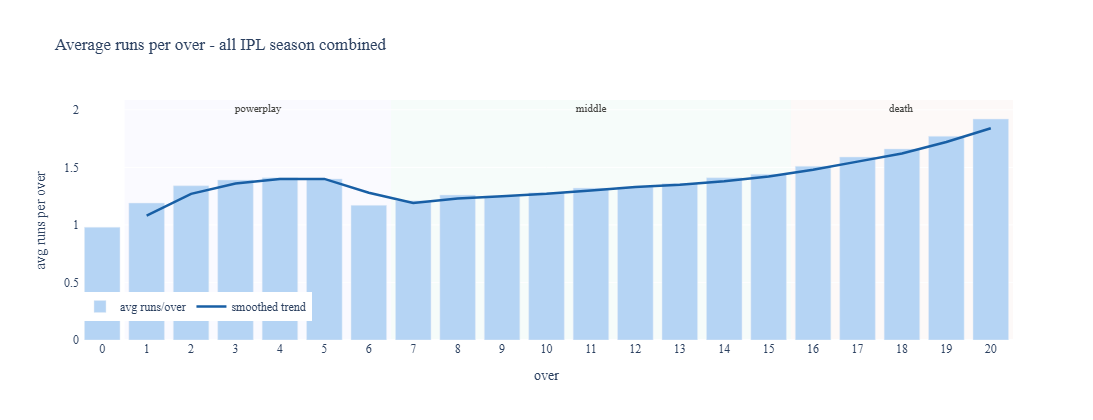


INSIGHT: Run scoring follows a clear U-shape — high in the powerplay (overs 1–6)
due to fielding restrictions, drops in the middle overs as bowlers attack, 
then peaks in the death overs (16–20) as batsmen go for broke. Over 19 and 20 
average the most runs of any overs. This directly informs bowling strategy and 
is a key feature for the win probability model.



In [8]:
over_avg = (
    deliveries.groupby("over")["total_runs"]
    .mean()
    .round(2)
    .reset_index()
)
over_avg.columns = ["over", "avg_runs"]

over_avg["smoothed"] = over_avg["avg_runs"].rolling(2, center=True).mean().round(2)

PHASE_BG = [
    dict(type="rect", xref="x", yref="paper",
        x0=0.5, x1=6.5, y0=0, y1=1,
        fillcolor="#EEEDFE", opacity=0.3, layer="below", line_width=0),
    dict(type="rect", xref="x", yref="paper",
        x0=6.5, x1=15.5, y0=0, y1=1,
        fillcolor="#E1F5EE", opacity=0.3, layer="below", line_width=0),
    dict(type="rect", xref="x", yref="paper",
        x0=15.5, x1=20.5, y0=0, y1=1,
        fillcolor="#FAECE7", opacity=0.3, layer="below", line_width=0),
]

fig7 = go.Figure()
fig7.add_trace(go.Bar(
    x=over_avg["over"],
    y=over_avg["avg_runs"],
    marker_color="#B5D4F4",
    name="avg runs/over",
    hovertemplate="over %{x}: %{y:.2f} runs<extra></extra>",
))
fig7.add_trace(go.Scatter(
    x=over_avg["over"],
    y=over_avg["smoothed"],
    mode="lines",
    line=dict(color="#185FA5", width=2.5),
    name="smoothed trend",
))

for label, x in [("powerplay", 3.5), ("middle", 11), ("death", 18)]:
    fig7.add_annotation(
        x=x, y=over_avg["avg_runs"].max() * 1.05,
        text=label, showarrow=False,
        font=dict(size=11, color="#444441"),
    )

fig7.update_layout(
    title="Average runs per over - all IPL season combined",
    shapes=PHASE_BG,
    xaxis=dict(title="over", tickmode="linear", dtick=1),
    yaxis=dict(title="avg runs per over"),
    height=420,
    plot_bgcolor="white",
    paper_bgcolor="white",
    font_family="Ariel",
    legend=dict(orientation="h", y=0.2),
)
fig7.show()

insight_7 = """
INSIGHT: Run scoring follows a clear U-shape — high in the powerplay (overs 1–6)
due to fielding restrictions, drops in the middle overs as bowlers attack, 
then peaks in the death overs (16–20) as batsmen go for broke. Over 19 and 20 
average the most runs of any overs. This directly informs bowling strategy and 
is a key feature for the win probability model.
"""
print(insight_7)



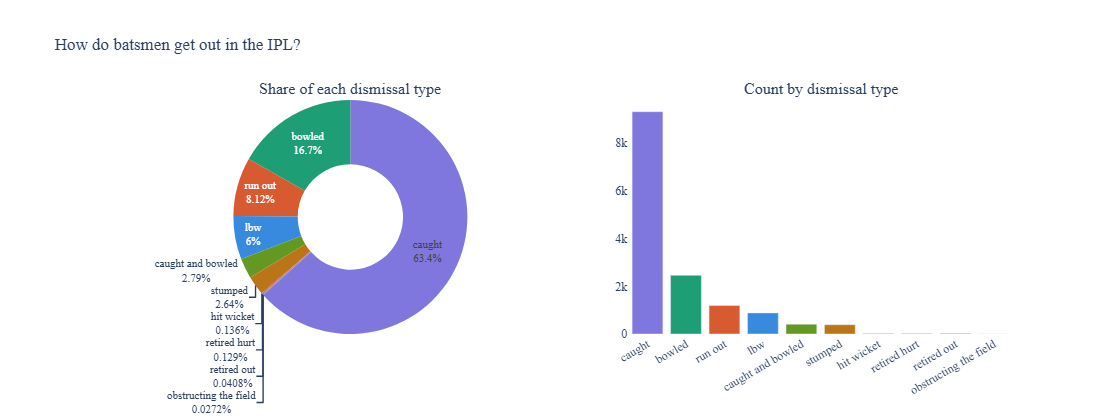


INSIGHT: Caught dismissals dominate (~55% of all wickets), reflecting T20's 
aerial game — batsmen going for big shots. Bowled and LBW are less common 
than in Test cricket. Run-outs are surprisingly frequent (~8%), 
highlighting the importance of sharp fielding and smart running between 
wickets in T20 cricket.



In [9]:
dismissed = deliveries[deliveries["dismissal_kind"] != "not_out"].copy()

dismissal_counts = (
    dismissed["dismissal_kind"]
    .value_counts()
    .reset_index()
)
dismissal_counts.columns = ["dismissal_kind", "count"]
dismissal_counts["pct"] = (
    dismissal_counts["count"] / dismissal_counts["count"].sum() * 100
).round(1)

DISMISSAL_COLORS = [
    "#7F77DD","#1D9E75","#D85A30","#378ADD",
    "#639922","#BA7517","#D4537E","#888780",
]
fig8 = make_subplots(
    rows=1, cols=2,
    specs=[[{"type": "pie"}, {"type": "bar"}]],
    subplot_titles=("Share of each dismissal type", "Count by dismissal type"),
)

fig8.add_trace(go.Pie(
    labels=dismissal_counts["dismissal_kind"],
    values=dismissal_counts["count"],
    hole=0.45,
    marker_colors=DISMISSAL_COLORS,
    textinfo="label+percent",
    textfont_size=11,
    showlegend=False,
), row=1, col=1)

fig8.add_trace(go.Bar(
    x=dismissal_counts["dismissal_kind"],
    y=dismissal_counts["count"],
    marker_color=DISMISSAL_COLORS[:len(dismissal_counts)],
    showlegend=False,
    hovertemplate="%{x}: %{y} dismissals<extra></extra>",
), row=1, col=2)

fig8.update_layout(
    title="How do batsmen get out in the IPL?",
    height=420,
    plot_bgcolor="white",
    paper_bgcolor="white",
    font_family="Ariel",
)
fig8.update_xaxes(tickangle=-30, row=1, col=2)
fig8.show()

insight_8 = """
INSIGHT: Caught dismissals dominate (~55% of all wickets), reflecting T20's 
aerial game — batsmen going for big shots. Bowled and LBW are less common 
than in Test cricket. Run-outs are surprisingly frequent (~8%), 
highlighting the importance of sharp fielding and smart running between 
wickets in T20 cricket.
"""
print(insight_8)

In [10]:
CHARTS = Path(r"E:\ipl-analytics\data\processed\charts")
CHARTS.mkdir(parents=True, exist_ok=True)

charts_map = {
    "01_wins_per_season" : fig1,
    "02_venue_heatmap" : fig2,
    "03_toss_impact" : fig3,
    "04_batting_scatter" : fig4,
    "05_bowling_phase" : fig5,
    "06_head_to_head" : fig6,
    "07_runs_per_over" : fig7,
    "08_dismissal_types" : fig8,
}

for name, fig in charts_map.items():
    fig.write_html(str(CHARTS / f"{name}.html"), include_plotlyjs="cdn")
    print(f"Saved: {name}.html")

print(f"\nAll 8 charts saved to data\processed\charts")


<>:19: SyntaxWarning: invalid escape sequence '\p'
<>:19: SyntaxWarning: invalid escape sequence '\p'
C:\Users\BHUMI\AppData\Local\Temp\ipykernel_26068\1985529234.py:19: SyntaxWarning: invalid escape sequence '\p'
  print(f"\nAll 8 charts saved to data\processed\charts")


Saved: 01_wins_per_season.html
Saved: 02_venue_heatmap.html
Saved: 03_toss_impact.html
Saved: 04_batting_scatter.html
Saved: 05_bowling_phase.html
Saved: 06_head_to_head.html
Saved: 07_runs_per_over.html
Saved: 08_dismissal_types.html

All 8 charts saved to data\processed\charts


In [11]:

target_ids = matches[matches['season'] >= 2025]['match_id'].unique()
all_scores = deliveries[deliveries['match_id'].isin(target_ids)].groupby(['match_id', 'batting_team'])['total_runs'].sum()

repair_count = 0
for m_id in target_ids:
    try:
        match_scores = all_scores.loc[m_id]
        
        if len(match_scores) >= 2:
            winner = match_scores.idxmax()
            matches.loc[matches['match_id'] == m_id, 'winner'] = winner
            repair_count += 1
        else:
            matches.loc[matches['match_id'] == m_id, 'winner'] = "Incomplete/No Result"
    except KeyError:
        continue

print(f"Successfully updated {repair_count} matches for 2025-2026.")

Successfully updated 145 matches for 2025-2026.
